## 1. Supervised Learning zur Klassifikation des Hypertoniestatus

Nach der Datenvorverarbeitung wurden in diesem Schritt verschiedene Klassifikationsmodelle trainiert, um vorherzusagen, ob bei einer Person Hypertonie vorliegt oder nicht. Grundlage dafür waren die zuvor ausgewählten Prädiktorvariablen wie Alter, Geschlecht, BMI, Taillenumfang sowie weitere gesundheitsbezogene Merkmale.

Die Daten wurden in Trainings- und Testdaten aufgeteilt, wobei eine stratifizierte Aufteilung genutzt wurde, um die Klassenverteilung der Zielvariable beizubehalten.

Da es sich bei der Zielvariable um eine binäre Klassifikation handelt, wurden  folgende geeignete Klassifikationsverfahren eingesetzt:
- Logistic Regression
- Random Forest
- Decision Tree

und anschließend miteinander verglichen. Ziel war es nicht nur, eine möglichst hohe Gesamtgenauigkeit zu erreichen, sondern insbesondere auch Personen mit Hypertonie zuverlässig zu erkennen.

Die Modellleistungen wurde anhand von Accuracy, Precision, Recall, F1-Score, ROC-AUC und der Confusion Matrix bewertet.

**Modellbewertung:**
Der Fokus der Modellbewertung dieser Analyse liegt auf einer möglichst hohen Sensitivität bzw. einem hohen Recall. Da das Modell in einem präventiven Screening-Kontext eingesetzt wird, sollen Personen mit Hypertonie möglichst selten fälschlicherweise als unauffällig klassifiziert werden.


#### 1. Datenladung und Vorbereitung für die Modellierung

In diesem Abschnitt wird der bereinigte Datensatz für die anschließende Modellierung vorbereitet. Dafür werden zunächst die Zielvariable sowie die relevanten Einflussvariablen definiert. Ziel ist es, ein Modell zu entwickeln, das anhand ausgewählter demografischer, anthropometrischer und gesundheitsbezogener Merkmale eine Hypertonie-Risikoeinschätzung ermöglicht.

Die Zielvariable lautet:

* `hypertension`: Gibt an, ob bei einer teilnehmenden Person Hypertonie vorliegt.

  * 0 = keine Hypertonie
  * 1 = Hypertonie

Für die Modellierung werden folgende Features berücksichtigt:

* `age`: Alter der teilnehmenden Person.
* `gender`: Geschlecht der teilnehmenden Person.
  * 1 = männlich
  * 2 = weiblich

* `bmi`: Body-Mass-Index der teilnehmenden Person.
* `waist_circumference(cm)`: Taillenumfang in Zentimetern.
* `current_smoker`: Aktueller Rauchstatus.

  * 0 = kein aktuelles Rauchen
  * 1 = aktuelles Rauchen

* `regular_alcohol_12m`: Alkoholkonsum ind letzten 12 Monaten.

  * ja = Alkoholkonsum liegt vor
  * nein = kein Alkoholkonsum

* `diabetes`: Gibt an, ob Diabetes vorliegt.

  * 0 = nein
  * 1 = ja
* `kidney_disease`: Gibt an, ob eine Nierenerkrankung vorliegt.

  * 0 = nein
  * 1 = ja
* `high_cholesterol`: Gibt an, ob ein erhöhter Cholesterinwert berichtet wurde.

  * 0 = nein
  * 1 = ja
* `sitting_hours_per_day`: Sitzzeit pro Tag in Stunden.
* `activity_level`: Körperliches Aktivitätsniveau der teilnehmenden Person.
  * 0 = nicht aktiv
  * 1 = moderat aktiv
  * 2 = intensiv aktiv

In [15]:
#Libraries importieren

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import  OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,precision_recall_curve,roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay


## 1. Datenladung


In [16]:

df = pd.read_csv('nhanes_cleand.csv')

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6042 entries, 0 to 6041
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   SEQN                     6042 non-null   float64
 1   hypertension             6042 non-null   float64
 2   high_cholesterol         6042 non-null   float64
 3   gender                   6042 non-null   str    
 4   age                      6042 non-null   float64
 5   weight(kg)               6042 non-null   float64
 6   height(cm)               6042 non-null   float64
 7   bmi                      6042 non-null   float64
 8   waist_circumference(cm)  6042 non-null   float64
 9   diabetes                 6042 non-null   float64
 10  kidney_disease           6042 non-null   float64
 11  current_smoker           6042 non-null   float64
 12  regular_alcohol_12m      6042 non-null   int64  
 13  activity_level           6042 non-null   int64  
 14  activity_level_label     6042 non-n

In [18]:
# Datenbereinigung
# famle und male durch 2 und 1 ersetzen 
# und datentype umwandeln in int

df['gender'] = df['gender'].replace({
    'Male' : '1',
    'Female' : '2'
})

df['gender'] = pd.to_numeric(df['gender'], errors= 'coerce')


### 2. Datenvorverarbeitung:

Im Rahmen der Datenvorverarbeitung wurde der bereinigte NHANES-Datensatz in Prädiktorvariablen (`X`) und Zielvariable (`y`) aufgeteilt. Die Zielvariable beschreibt, ob bei einer Person Hypertonie vorliegt oder nicht.

Anschließend wurde der Datensatz in Trainings- und Testdaten aufgeteilt. Dabei wurden 80 % der Daten für das Training des Modells und 20 % für die spätere Modellbewertung verwendet.

Da die explorative Datenanalyse gezeigt hat, dass die Zielvariable nicht vollständig gleich verteilt ist, wurde beim Train-Test-Split eine stratifizierte Aufteilung verwendet (`stratify=y`). Dadurch bleibt das Verhältnis der beiden Zielklassen sowohl im Trainings- als auch im Testdatensatz möglichst ähnlich.

Die Zielvariable war ungefähr wie folgt verteilt:

* ca. 65 % der Personen ohne Hypertonie
* ca. 35 % der Personen mit Hypertonie

Damit liegt eine leichte bis moderate Klassenungleichverteilung vor. Diese ist nicht extrem, muss jedoch bei der Bewertung des Modells berücksichtigt werden. Ein Modell könnte sonst überwiegend die Mehrheitsklasse „keine Hypertonie“ vorhersagen und trotzdem eine scheinbar akzeptable Accuracy erreichen.

Aus diesem Grund wurde die Modellleistung nicht ausschließlich anhand der Accuracy bewertet. Zusätzlich wurden weitere Bewertungsmetriken wie Precision, Recall, F1-Score und die Confusion Matrix betrachtet, um insbesondere die Erkennung von Personen mit Hypertonie besser beurteilen zu können.


In [19]:

#features 
X = df[
    [
        "age",
        "gender",
        "bmi",
        "high_cholesterol",
        "waist_circumference(cm)",
        "sitting_hours_per_day",
        "current_smoker",
        "regular_alcohol_12m",
        "diabetes",
        "kidney_disease",
        "activity_level"
        
    ]
]

#Target 
y = df["hypertension"]


In [20]:
# Train-Test-Split 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print( 'X_train', X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train (4833, 11)
X_test: (1209, 11)
y_train: (4833,)
y_test: (1209,)


# 3.Modelltraining

## 3.1 Logistic Regression

Im nächsten Schritt wurden Klassifikationsmodelle trainiert, um das Vorliegen von Hypertonie anhand der ausgewählten Merkmale vorherzusagen. Die Modelle wurden ausschließlich mit den Trainingsdaten trainiert, während die Testdaten für die spätere Bewertung zurückgehalten wurden.

Da die Zielvariable zwei Ausprägungen besitzt — Hypertonie ja oder nein — handelt es sich um ein binäres Klassifikationsproblem. Ziel des Modelltrainings war es, Muster in den Daten zu erkennen und daraus möglichst zuverlässige Vorhersagen für bisher unbekannte Personen abzuleiten.

Nach der ersten Modellierung wurden folgende Anpassungen vorgenommen, um die Modellleistung zu verbessern.

Mögliche Verbesserungsansätze waren:
- die Verwendung von class_weight="balanced" (für die Berücksichtigung der ungleichen Klassenverteilung)
- die Anpassung des Entscheidungsschwellenwertes
- der Vergleich verschiedener Klassifikationsmodelle sowie die Prüfung zusätzlicher relevanter Risikofaktoren.

Durch die Senkung des Schwellenwertes von 0,5 auf 0,4 erhöhte sich bei allen Modellen der Recall der Hypertonie-Klasse. Das bedeutet, dass mehr tatsächliche Hypertonie-Fälle korrekt erkannt wurden. Gleichzeitig sank jedoch die Precision, da mehr Personen ohne Hypertonie fälschlicherweise als hyperton klassifiziert wurden.


Accuracy: 0.738626964433416
Precision weighted: 0.7541493732674556
Recall weighted: 0.738626964433416
F1 weighted: 0.7419558910590809
Recall Hypertonie: 0.7592190889370932
Precision Hypertonie: 0.6306306306306306
F1 Hypertonie: 0.6889763779527559


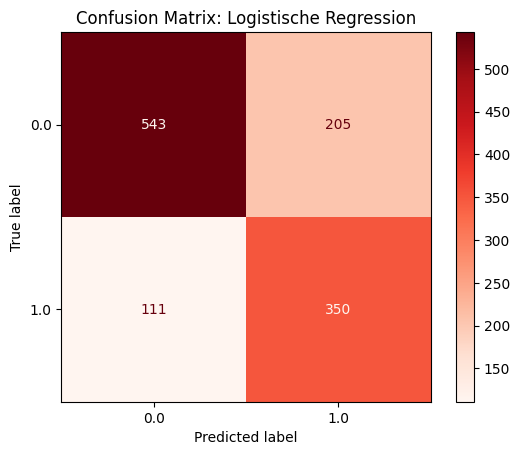

In [21]:
#Modelltraining  nach Klasse logistische Regression 
# daten standardisiert
log_model = Pipeline ([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter= 1000,
                                 class_weight= 'balanced'))
])

#model trainieren 
log_model.fit(X_train, y_train)

# Vorhersagen für die Testdaten

y_pred_log = log_model.predict(X_test)

# Modellbewertung
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision weighted:", precision_score(y_test, y_pred_log, average="weighted"))
print("Recall weighted:", recall_score(y_test, y_pred_log, average="weighted"))
print("F1 weighted:", f1_score(y_test, y_pred_log, average="weighted"))

# Fokus auf positive Klasse: Hypertonie
print("Recall Hypertonie:", recall_score(y_test, y_pred_log, pos_label=1))
print("Precision Hypertonie:", precision_score(y_test,y_pred_log, pos_label=1))
print("F1 Hypertonie:", f1_score(y_test, y_pred_log, pos_label=1))


# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    cmap="Reds"
)

plt.title("Confusion Matrix: Logistische Regression")
plt.show()


Die Confusion Matrix zeigt, dass das Modell 350 Personen mit Hypertonie korrekt erkannt hat, während 111 Personen mit Hypertonie fälschlicherweise als nicht hyperton klassifiziert wurden. Der Recall der positiven Klasse beträgt 0,76. Damit erkennt das Modell etwa 76 % der tatsächlichen Hypertonie-Fälle. Gleichzeitig wurden 206 Personen ohne Hypertonie fälschlicherweise als hyperton klassifiziert. Dies zeigt, dass das Modell eine relativ hohe Sensitivität für Hypertonie erreicht, jedoch auf Kosten einer höheren Anzahl falsch-positiver Vorhersagen. Da in diesem Projekt ein präventiver Screening-Kontext betrachtet wird, ist ein höherer Recall der Hypertonie-Klasse besonders relevant.

Die gewichtete Precision liegt über der Precision der Hypertonie-Klasse, da sie beide Klassen berücksichtigt und die Klasse ohne Hypertonie eine deutlich höhere Precision aufweist. Deshalb wurde zusätzlich die Precision der positiven Klasse separat betrachtet, um die Modellleistung für die Erkennung von Hypertonie gezielt zu bewerten.

### Anpassung der Entscheidungsschwellenwert

Zusätzlich wurde der Entscheidungsschwellenwert angepasst. Standardmäßig klassifiziert das Modell Personen ab einer Wahrscheinlichkeit von 0,5 als hyperton.
Da in diesem Projekt die Erkennung möglichst vieler Hypertonie-Fälle im Vordergrund steht, wurde ein niedrigerer Schwellenwert getestet. Dadurch können mehr tatsächliche Hypertonie-Fälle erkannt werden, allerdings steigt gleichzeitig die Anzahl falsch-positiver Vorhersagen.

Metriken mit Schwellenwert: 0.4
Accuracy: 0.6980976013234078
Precision weighted: 0.7532190546016689
Recall weighted: 0.6980976013234078
F1 weighted: 0.7009864966262012
Recall Hypertonie: 0.8481561822125814
Precision Hypertonie: 0.5699708454810496
F1 Hypertonie: 0.6817785527462947


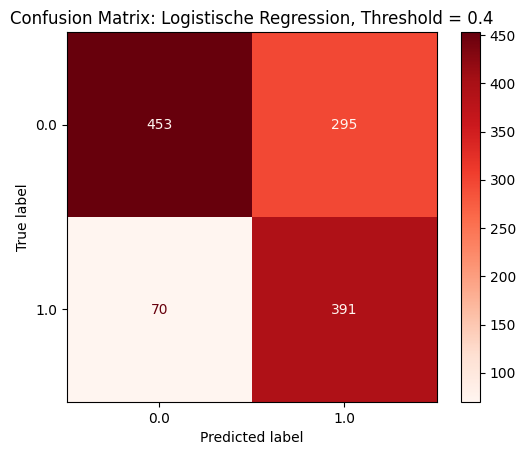

In [22]:
# Wahrscheinlichkeiten für Klasse 1 = Hypertonie mit (threshold = 0.5)
y_proba_log = log_model.predict_proba(X_test)[:, 1]

# eigener Schwellenwert
threshold = 0.4

# neue Vorhersage anhand des Schwellenwerts /Klassifikation mit niedrigerem Schwellenwert 0.4
y_pred_threshold = (y_proba_log >= threshold).astype(int)
print("Metriken mit Schwellenwert:", threshold)

print("Accuracy:", accuracy_score(y_test, y_pred_threshold))
print("Precision weighted:", precision_score(y_test, y_pred_threshold, average="weighted"))
print("Recall weighted:", recall_score(y_test, y_pred_threshold, average="weighted"))
print("F1 weighted:", f1_score(y_test, y_pred_threshold, average="weighted"))

print("Recall Hypertonie:", recall_score(y_test, y_pred_threshold, pos_label=1))
print("Precision Hypertonie:", precision_score(y_test, y_pred_threshold, pos_label=1))
print("F1 Hypertonie:", f1_score(y_test, y_pred_threshold, pos_label=1))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_threshold,
    cmap="Reds"
)

plt.title(f"Confusion Matrix: Logistische Regression, Threshold = {threshold}")
plt.show()

In [23]:
roc_auc_log = roc_auc_score(y_test, y_proba_log)
print("ROC-AUC Logistic Regression:",roc_auc_log)

ROC-AUC Logistic Regression: 0.8144611226466528


Die logistische Regression erreichte eine ROC-AUC von 0,81. Dies zeigt, dass das Modell eine gute Trennfähigkeit zwischen Personen mit und ohne Hypertonie besitzt. Im Gegensatz zu Accuracy, Precision oder Recall bewertet die ROC-AUC nicht nur eine feste Klassifikation, sondern die Trennfähigkeit des Modells über verschiedene Entscheidungsschwellen hinweg.

##### Vergleich: Standard-Threshold vs. Threshold 0.4

Im ersten Schritt wurde das Modell mit der Standardklassifikation bewertet. Dabei erreichte die logistische Regression eine Accuracy von 0,738 und einen Recall der Hypertonie-Klasse von 0,76. Die Confusion Matrix zeigte, dass 350 von 461 Personen mit Hypertonie korrekt erkannt wurden, während 111 Fälle übersehen wurden.

Anschließend wurde mithilfe der vorhergesagten Wahrscheinlichkeiten aus `predict_proba()`der Entscheidungsschwellenwert auf 
0,4 gesenkt. Dadurch erhöhte sich der Recall der Hypertonie-Klasse auf 0,85. Die Anzahl übersehener Hypertonie-Fälle sank von 111 auf 70. Gleichzeitig nahm jedoch die Anzahl falsch-positiver Vorhersagen von 205 auf 295 zu, wodurch die Precision der Hypertonie-Klasse von 0,63 auf 0,57 sank.

Da das Projekt in einem präventiven Screening-Kontext steht, ist ein höherer Recall besonders relevant. Die Schwellenwertanpassung zeigt daher, dass das Modell sensitiver für Hypertonie-Fälle gemacht werden kann, allerdings auf Kosten einer höheren Anzahl falsch-positiver Klassifikationen.

## 3.2 Random Forest

Zusätzlich zur logistischen Regression wurde ein Random-Forest-Modell getestet. Random Forest ist ein nicht-lineares Ensemble-Verfahren und kann komplexere Zusammenhänge zwischen den Prädiktoren und der Zielvariable abbilden. Dadurch kann geprüft werden, ob ein flexibleres Modell die Vorhersage von Hypertonie verbessert. Zur Berücksichtigung der ungleichen Klassenverteilung wurde ebenfalls class_weight="balanced" verwendet.

Metriken Random Forest mit Standard-Threshold
Accuracy: 0.7295285359801489
Precision weighted: 0.7247754285466612
Recall weighted: 0.7295285359801489
F1 weighted: 0.7250751456007769
Recall Hypertonie: 0.5770065075921909
Precision Hypertonie: 0.6683417085427136
F1 Hypertonie: 0.619324796274738


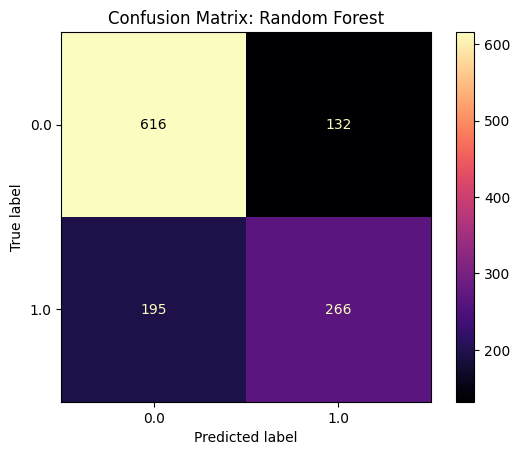

In [24]:
forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

# Modell trainieren
forest_model.fit(X_train, y_train)

# Vorhersagen für die Testdaten
y_pred_forest = forest_model.predict(X_test)

print("Metriken Random Forest mit Standard-Threshold")

print("Accuracy:", accuracy_score(y_test, y_pred_forest))
print("Precision weighted:", precision_score(y_test, y_pred_forest, average="weighted"))
print("Recall weighted:", recall_score(y_test, y_pred_forest, average="weighted"))
print("F1 weighted:", f1_score(y_test, y_pred_forest, average="weighted"))

print("Recall Hypertonie:", recall_score(y_test, y_pred_forest, pos_label=1))
print("Precision Hypertonie:", precision_score(y_test, y_pred_forest, pos_label=1))
print("F1 Hypertonie:", f1_score(y_test, y_pred_forest, pos_label=1))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_forest,
    cmap='magma'
)

plt.title("Confusion Matrix: Random Forest")
plt.show()

In [25]:
y_proba_rf = forest_model.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("ROC-AUC Random Forest:", roc_auc_rf)

ROC-AUC Random Forest: 0.7839749092301089


Der Random Forest erreichte eine ROC-AUC von 0,78. Dies zeigt eine akzeptable Trennfähigkeit zwischen Personen mit und ohne Hypertonie. Im Vergleich zur logistischen Regression, die eine ROC-AUC von 0,81 erreichte, schnitt der Random Forest hinsichtlich der allgemeinen Trennfähigkeit etwas schwächer ab.

##### Anpassung der Entscheidungsschwellenwert


Metriken Random Forest mit Schwellenwert: 0.4
Accuracy: 0.7088502894954508
Precision weighted: 0.7205959922634836
Recall weighted: 0.7088502894954508
F1 weighted: 0.7120904666153034
Recall Hypertonie: 0.6984815618221258
Precision Hypertonie: 0.6018691588785047
F1 Hypertonie: 0.6465863453815262


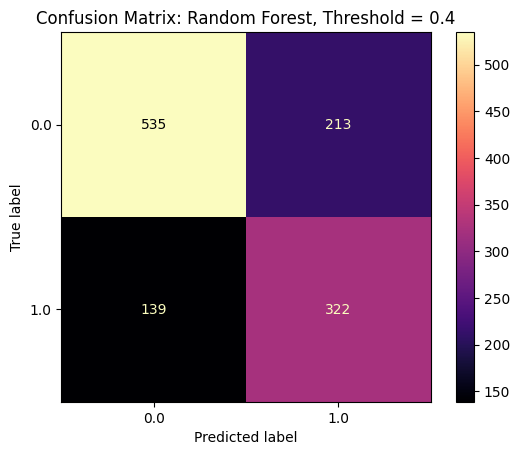

In [26]:
threshold = 0.4

y_pred_rf_threshold = (y_proba_rf >= threshold).astype(int)

print("Metriken Random Forest mit Schwellenwert:", threshold)

print("Accuracy:", accuracy_score(y_test, y_pred_rf_threshold))
print("Precision weighted:", precision_score(y_test, y_pred_rf_threshold, average="weighted"))
print("Recall weighted:", recall_score(y_test, y_pred_rf_threshold, average="weighted"))
print("F1 weighted:", f1_score(y_test, y_pred_rf_threshold, average="weighted"))

print("Recall Hypertonie:", recall_score(y_test, y_pred_rf_threshold, pos_label=1))
print("Precision Hypertonie:", precision_score(y_test, y_pred_rf_threshold, pos_label=1))
print("F1 Hypertonie:", f1_score(y_test, y_pred_rf_threshold, pos_label=1))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_threshold,
    cmap='magma'
)

plt.title("Confusion Matrix: Random Forest, Threshold = 0.4")
plt.show()

Beim Random-Forest-Modell wurde zunächst die Standardklassifikation bewertet. Dabei erreichte das Modell eine Accuracy von 0,72. Der Recall der Hypertonie-Klasse lag jedoch nur bei 0,57. Das bedeutet, dass das Modell nur etwa 50 % der tatsächlichen Hypertonie-Fälle korrekt erkannt hat. Die Precision der Hypertonie-Klasse lag bei 0,66.

Nach Anpassung des Schwellenwertes auf 0,4 verbesserte sich der Recall der Hypertonie-Klasse auf 0,69. Dadurch wurden mehr Personen mit Hypertonie erkannt. Gleichzeitig sank die Precision leicht auf 0,60, da mehr Personen ohne Hypertonie fälschlicherweise als hyperton klassifiziert wurden. Die Accuracy blieb mit 0,71 nahezu unverändert.

## 3.3 Decision Tree

Zusätzlich wurde ein Decision-Tree-Modell getestet. Decision Trees können nicht-lineare Zusammenhänge zwischen den unabhängigen Variablen und der Zielvariable abbilden und sind aufgrund ihrer Baumstruktur gut interpretierbar. Zur Berücksichtigung der ungleichen Klassenverteilung wurde class_weight="balanced" verwendet. Anschließend wurde die Modellleistung anhand von Accuracy, Precision, Recall, F1-Score, Confusion Matrix und ROC-AUC bewertet.


Metriken Decision Tree mit Standard-Threshold
Accuracy: 0.7096774193548387
Precision weighted: 0.7196810127827984
Recall weighted: 0.7096774193548387
F1 weighted: 0.7126435505762373
Recall Hypertonie: 0.6898047722342733
Precision Hypertonie: 0.6045627376425855
F1 Hypertonie: 0.6443768996960486


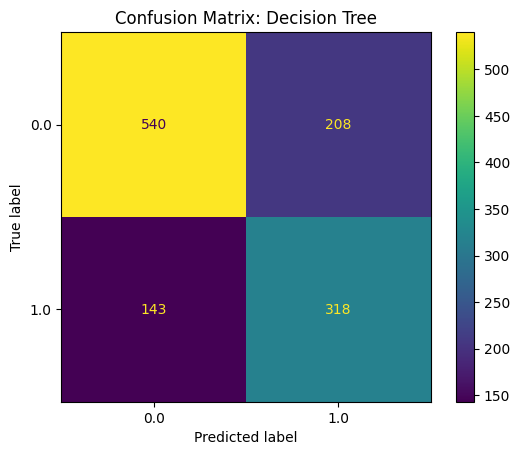

In [27]:
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

# Modell trainieren
tree_model.fit(X_train, y_train)

# Vorhersagen für die Testdaten
y_pred_tree = tree_model.predict(X_test)

print("Metriken Decision Tree mit Standard-Threshold")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision weighted:", precision_score(y_test, y_pred_tree, average="weighted"))
print("Recall weighted:", recall_score(y_test, y_pred_tree, average="weighted"))
print("F1 weighted:", f1_score(y_test, y_pred_tree, average="weighted"))

print("Recall Hypertonie:", recall_score(y_test, y_pred_tree, pos_label=1))
print("Precision Hypertonie:", precision_score(y_test, y_pred_tree, pos_label=1))
print("F1 Hypertonie:", f1_score(y_test, y_pred_tree, pos_label=1))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tree,
    cmap='viridis'
)

plt.title("Confusion Matrix: Decision Tree")
plt.show()

In [28]:
y_proba_tree = tree_model.predict_proba(X_test)[:, 1]

roc_auc_tree = roc_auc_score(y_test, y_proba_tree)

print("ROC-AUC Decision Tree:", roc_auc_tree)

ROC-AUC Decision Tree: 0.7802658136810237


Für den Decision Tree wurde zusätzlich die ROC-AUC berechnet. Dafür wurden mit predict_proba() die vorhergesagten Wahrscheinlichkeiten für die positive Klasse, also Hypertonie, verwendet. Die ROC-AUC beträgt 0,78 und zeigt damit eine akzeptable bis gute Trennfähigkeit zwischen Personen mit und ohne Hypertonie.

Metriken Decision Tree mit Schwellenwert: 0.4
Accuracy: 0.6708023159636063
Precision weighted: 0.7533881423213737
Recall weighted: 0.6708023159636063
F1 weighted: 0.6704734912478777
Recall Hypertonie: 0.8850325379609545
Precision Hypertonie: 0.5418326693227091
F1 Hypertonie: 0.6721581548599671


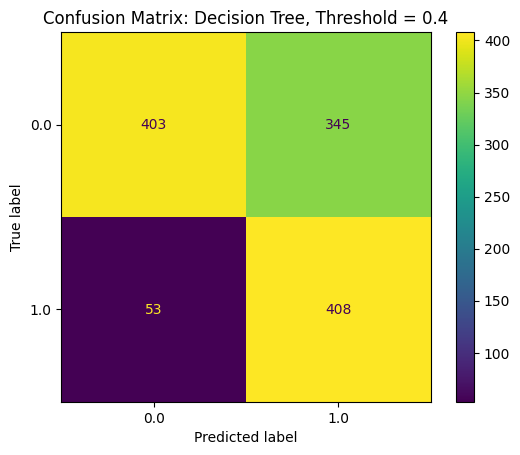

In [29]:
threshold = 0.4

y_pred_tree_threshold = (y_proba_tree >= threshold).astype(int)

print("Metriken Decision Tree mit Schwellenwert:", threshold)

print("Accuracy:", accuracy_score(y_test, y_pred_tree_threshold))
print("Precision weighted:", precision_score(y_test, y_pred_tree_threshold, average="weighted"))
print("Recall weighted:", recall_score(y_test, y_pred_tree_threshold, average="weighted"))
print("F1 weighted:", f1_score(y_test, y_pred_tree_threshold, average="weighted"))

print("Recall Hypertonie:", recall_score(y_test, y_pred_tree_threshold, pos_label=1))
print("Precision Hypertonie:", precision_score(y_test, y_pred_tree_threshold, pos_label=1))
print("F1 Hypertonie:", f1_score(y_test, y_pred_tree_threshold, pos_label=1))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tree_threshold,
    cmap='viridis'
)

plt.title("Confusion Matrix: Decision Tree, Threshold = 0.4")
plt.show()

Durch die Senkung des Entscheidungsschwellenwertes von 0,5 auf 0,4 erhöhte sich der Recall der Hypertonie-Klasse beim Decision Tree deutlich von 0,69 auf 0,88. Die Anzahl übersehener Hypertonie-Fälle sank von 143 auf 53. Gleichzeitig stieg jedoch die Anzahl falsch-positiver Klassifikationen von 208 auf 345, wodurch die Precision der Hypertonie-Klasse von 0,60 auf 0,54 sank. Der niedrigere Schwellenwert führt somit zu einer höheren Sensitivität, jedoch auf Kosten einer geringeren Spezifität und einer deutlich höheren Anzahl falscher Warnungen.

## 4.Modellvergelich

In [32]:
results = pd.DataFrame({
    
    "Modell": [
        "LogReg (0.5)",
        "LogReg (0.4)",
        "Random Forest (0.5)",
        "Random Forest (0.4)",
        "Decision Tree (0.5)",
        "Decision Tree (0.4)"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_threshold),
        accuracy_score(y_test, y_pred_forest),
        accuracy_score(y_test, y_pred_rf_threshold),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_tree_threshold)
    ],
    
    "Recall_Hypertonie": [
        recall_score(y_test, y_pred_log, pos_label=1),
        recall_score(y_test, y_pred_threshold, pos_label=1),
        recall_score(y_test, y_pred_forest, pos_label=1),
        recall_score(y_test, y_pred_rf_threshold, pos_label=1),
        recall_score(y_test, y_pred_tree, pos_label=1),
        recall_score(y_test, y_pred_tree_threshold, pos_label=1)
    ],
    
    "Precision_Hypertonie": [
        precision_score(y_test, y_pred_log, pos_label=1),
        precision_score(y_test, y_pred_threshold, pos_label=1),
        precision_score(y_test, y_pred_forest, pos_label=1),
        precision_score(y_test, y_pred_rf_threshold, pos_label=1),
        precision_score(y_test, y_pred_tree, pos_label=1),
        precision_score(y_test, y_pred_tree_threshold, pos_label=1)
    ],
    
    "F1_Hypertonie": [
        f1_score(y_test, y_pred_log, pos_label=1),
        f1_score(y_test, y_pred_threshold, pos_label=1),
        f1_score(y_test, y_pred_forest, pos_label=1),
        f1_score(y_test, y_pred_rf_threshold, pos_label=1),
        f1_score(y_test, y_pred_tree, pos_label=1),
        f1_score(y_test, y_pred_tree_threshold, pos_label=1)
    ],
    
    "ROC_AUC": [
        roc_auc_log,
        roc_auc_log,
        roc_auc_rf,
        roc_auc_rf,
        roc_auc_tree,
        roc_auc_tree
    ]
})

print(results)

results.sort_values(
    by=["Recall_Hypertonie", "F1_Hypertonie", "ROC_AUC"],
    ascending=[False, False, False]
)

                Modell  Accuracy  Recall_Hypertonie  Precision_Hypertonie  \
0         LogReg (0.5)  0.738627           0.759219              0.630631   
1         LogReg (0.4)  0.698098           0.848156              0.569971   
2  Random Forest (0.5)  0.729529           0.577007              0.668342   
3  Random Forest (0.4)  0.708850           0.698482              0.601869   
4  Decision Tree (0.5)  0.709677           0.689805              0.604563   
5  Decision Tree (0.4)  0.670802           0.885033              0.541833   

   F1_Hypertonie   ROC_AUC  
0       0.688976  0.814461  
1       0.681779  0.814461  
2       0.619325  0.783975  
3       0.646586  0.783975  
4       0.644377  0.780266  
5       0.672158  0.780266  


,Modell,Accuracy,Recall_Hypertonie,Precision_Hypertonie,F1_Hypertonie,ROC_AUC
5,Decision Tree (0.4),0.670802,0.885033,0.541833,0.672158,0.780266
1,LogReg (0.4),0.698098,0.848156,0.569971,0.681779,0.814461
0,LogReg (0.5),0.738627,0.759219,0.630631,0.688976,0.814461
3,Random Forest (0.4),0.708850,0.698482,0.601869,0.646586,0.783975
4,Decision Tree (0.5),0.709677,0.689805,0.604563,0.644377,0.780266
2,Random Forest (0.5),0.729529,0.577007,0.668342,0.619325,0.783975


### Modell-Auswahl:

Im Rahmen des Modellvergleichs wurden logistische Regression, Random Forest und Decision Tree hinsichtlich ihrer Eignung zur Hypertonie-Klassifikation untersucht. Da das Projekt in einem präventiven Screening-Kontext steht, wurde neben der allgemeinen Modellleistung insbesondere der Recall der positiven Klasse betrachtet. Zusätzlich wurden Precision, F1-Score und ROC-AUC herangezogen, um eine einseitige Bewertung anhand des Recalls zu vermeiden.

Die logistische Regression erreichte mit einer ROC-AUC von 0,814 die beste Trennfähigkeit zwischen Personen mit und ohne Hypertonie. Bei einem Standardschwellenwert von 0,5 lag der Recall der Hypertonie-Klasse bei 0,76. Durch Senkung des Entscheidungsschwellenwertes auf 0,4 konnte der Recall auf 0,85 erhöht werden. Gleichzeitig sank die Precision von 0,63 auf 0,57, was auf eine höhere Anzahl falsch-positiver Vorhersagen hinweist. Der F1-Score blieb jedoch mit 0,68 nahezu stabil.

Der Decision Tree mit Schwellenwert 0,4 erzielte zwar mit 0,88 den höchsten Recall, zeigte jedoch gleichzeitig eine deutlich niedrigere Accuracy und Precision sowie eine geringere ROC-AUC. In der Confusion Matrix wurde sichtbar, dass der Decision Tree im Vergleich zur logistischen Regression zwar 17 zusätzliche Hypertonie-Fälle erkannte, jedoch 50 zusätzliche falsch-positive Vorhersagen erzeugte.

Insgesamt wurde daher die logistische Regression mit einem Schwellenwert von 0,4 als finales Modell ausgewählt. Dieses Modell bietet eine gute Balance zwischen hoher Sensitivität für Hypertonie-Fälle, stabiler Gesamtleistung und guter Interpretierbarkeit. Für die geplante Streamlit-Anwendung ist diese Kombination besonders geeignet, da die Anwendung keine Diagnose stellen, sondern eine modellbasierte Risikoeinschätzung unterstützen soll.

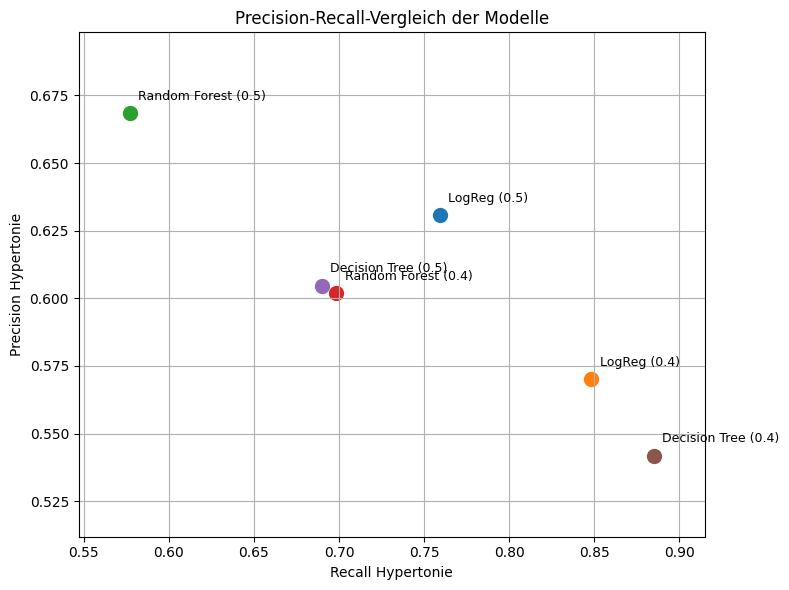

In [33]:
plt.figure(figsize=(8, 6))

for _, row in results.iterrows():
    plt.scatter(
        row["Recall_Hypertonie"],
        row["Precision_Hypertonie"],
        s=100
    )
    
    plt.text(
        row["Recall_Hypertonie"] + 0.005,
        row["Precision_Hypertonie"] + 0.005,
        row["Modell"],
        fontsize=9
    )

# automatische Achsengrenzen mit kleinem Abstand
x_min = results["Recall_Hypertonie"].min() - 0.03
x_max = results["Recall_Hypertonie"].max() + 0.03

y_min = results["Precision_Hypertonie"].min() - 0.03
y_max = results["Precision_Hypertonie"].max() + 0.03

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.xlabel("Recall Hypertonie")
plt.ylabel("Precision Hypertonie")
plt.title("Precision-Recall-Vergleich der Modelle")
plt.grid(True)
plt.tight_layout()
plt.show()

Die Precision-Recall-Darstellung zeigt den Zielkonflikt zwischen Sensitivität und Vorhersagegenauigkeit der positiven Klasse. Modelle weiter rechts erkennen mehr tatsächliche Hypertonie-Fälle, während Modelle weiter oben weniger falsch-positive Hypertonie-Vorhersagen erzeugen. Durch die Senkung des Schwellenwertes von 0,5 auf 0,4 verschieben sich die Modelle erwartungsgemäß nach rechts, da der Recall steigt. Gleichzeitig sinkt die Precision, da mehr Personen ohne Hypertonie fälschlicherweise als hyperton klassifiziert werden. Die logistische Regression mit Schwellenwert 0,4 stellt dabei einen geeigneten Kompromiss dar, da sie einen hohen Recall erreicht und gleichzeitig eine bessere Precision als der Decision Tree mit Schwellenwert 0,4 aufweist.

- hoher Recall = mehr Hypertonie-Fälle erkannt
- hohe Precision = weniger falsch-positive Fälle

## Hypertonie-Risikoeinschätzung 

Nach der Modellierung wurde eine Feature-Importance-Analyse durchgeführt, um zu untersuchen, welche Eingangsvariablen die Vorhersage des Modells am stärksten beeinflussen. Die Analyse dient dazu, die Modellentscheidung besser nachvollziehbar zu machen und die Auswahl der Eingabevariablen für die Streamlit-Anwendung zu begründen.

Für die Anwendung sollen vor allem Merkmale berücksichtigt werden, die sowohl für das Modell relevant als auch für Nutzerinnen und Nutzer einfach selbst anzugeben sind. Dazu gehören beispielsweise Alter, Geschlecht, BMI, Taillenumfang sowie ausgewählte Lebensstilfaktoren. Laborwerte oder schwer zugängliche medizinische Informationen werden nicht einbezogen, um die Anwendung benutzerfreundlich zu halten.

Die Streamlit-App nutzt das trainierte Modell, um auf Grundlage der eingegebenen Werte eine Einschätzung für ein erhöhtes Hypertonie-Risiko auszugeben. Dabei handelt es sich nicht um eine medizinische Diagnose, sondern um ein datenbasiertes Screening-Modell. Die Anwendung kann mögliche Risikokonstellationen sichtbar machen, ersetzt jedoch keine ärztliche Untersuchung oder Blutdruckmessung.

### Feature-Importance-Analyse

Da als finales Modell eine logistische Regression verwendet wurde, basiert die Feature-Importance-Analyse auf den geschätzten **Modellkoeffizienten**. 


### Feature-Importance-Tabelle

Zur Interpretation der logistischen Regression wurden drei Kennwerte in der Feature-Importance-Tabelle dargestellt:

- Coefficient
- Odds_Ratio
- Importance_abs

Diese drei Spalten erfüllen unterschiedliche Funktionen und ergänzen sich gegenseitig.

1.  Der **Koeffizient** zeigt die Richtung des Zusammenhangs zwischen einem Merkmal und der vorhergesagten Hypertonie-Wahrscheinlichkeit. Positive Koeffizienten weisen auf eine höhere, negative Koeffizienten auf eine niedrigere vorhergesagte Wahrscheinlichkeit hin.
2. Da die Koeffizienten der logistischen Regression in Log-Odds angegeben werden, wurden sie zusätzlich in **Odds Ratios** transformiert. Dadurch lässt sich die Richtung und Stärke der Zusammenhänge leichter interpretieren.


| Odds Ratio | Bedeutung                      |
| ---------: | ------------------------------ |
|        > 1 | höhere Odds für Hypertonie     |
|        < 1 | niedrigere Odds für Hypertonie |
|        = 1 | kein relevanter Unterschied    |

3. Der absolute Koeffizient wurde als **Importance-Wert** verwendet, um die relative Bedeutung der Merkmale unabhängig von der Richtung des Zusammenhangs zu vergleichen. 

Da die Features vor der Modellierung standardisiert wurden, beziehen sich die Koeffizienten und Odds Ratios auf standardisierte Werte. Die Werte eignen sich daher besonders zum Vergleich der Merkmale innerhalb des Modells.



In [26]:
print(log_model.named_steps)

{'scaler': StandardScaler(), 'model': LogisticRegression(class_weight='balanced', max_iter=1000)}


In [34]:
feature_names = X_train.columns
# Koeffizienten aus der logistischen Regression holen
coefficients = log_model.named_steps["model"].coef_[0]

# DataFrame erstellen
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Importance": abs(coefficients)
})

# Nach Stärke des Einflusses sortieren
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Coefficient,Importance
0,age,0.819283,0.819283
2,bmi,0.398022,0.398022
3,high_cholesterol,0.369505,0.369505
8,diabetes,0.305813,0.305813
9,kidney_disease,0.194826,0.194826
6,current_smoker,0.144584,0.144584
4,waist_circumference(cm),0.129421,0.129421
10,activity_level,-0.056916,0.056916
5,sitting_hours_per_day,0.039041,0.039041
1,gender,-0.028308,0.028308


### Interpretation der Feature-Importance-Analyse

Die Feature-Importance-Analyse zeigt, dass das Alter den stärksten Einfluss auf die Vorhersage des logistischen Regressionsmodells hat. Der Koeffizient für `age` ist positiv und weist mit einem Importance-Wert von 0.819 den höchsten Wert auf. Das bedeutet, dass ein höheres Alter im Modell mit einer höheren Wahrscheinlichkeit für die Klasse „Hypertonie“ verbunden ist.

An zweiter Stelle steht der `BMI` mit einem positiven Koeffizienten von 0.398. Auch diese Variable erhöht im Modell die Wahrscheinlichkeit für Hypertonie. Dies ist fachlich plausibel, da ein höherer BMI häufig mit einem erhöhten kardiometabolischen Risiko und damit auch mit Hypertonie verbunden ist.

Der erhöhte Cholesterinstatus `high_cholesterol` weist ebenfalls einen positiven Koeffizienten von 0.370 auf. Das bedeutet, dass Personen mit erhöhtem Cholesterinstatus im Modell eher der Klasse „Hypertonie“ zugeordnet werden. Dieser Zusammenhang ist fachlich nachvollziehbar, da Hypertonie und erhöhte Cholesterinwerte häufig gemeinsame Risikoprofile im Bereich Herz-Kreislauf-Gesundheit aufweisen.

Auch die Variable `diabetes` zeigt mit einem Koeffizienten von 0.306 einen positiven Einfluss auf die Hypertonie-Vorhersage. Personen mit Diabetes haben im Modell somit eine höhere Wahrscheinlichkeit, als hyperton klassifiziert zu werden. Dies ist fachlich plausibel, da Diabetes und Hypertonie häufig gemeinsam auftreten und beide wichtige Risikofaktoren für kardiovaskuläre Erkrankungen darstellen.

Die Variable `kidney_disease` hat ebenfalls einen positiven Koeffizienten von 0.195. Eine chronische Nierenerkrankung ist im Modell somit mit einer höheren Wahrscheinlichkeit für Hypertonie verbunden. Dieser Befund ist medizinisch nachvollziehbar, da Nierenerkrankungen und Blutdruckregulation eng miteinander zusammenhängen.

Der aktuelle Raucherstatus `current_smoker` weist einen positiven Koeffizienten von 0.145 auf. Das bedeutet, dass aktuelles Rauchen im Modell eher mit einer höheren Wahrscheinlichkeit für Hypertonie verbunden ist. Der Einfluss ist jedoch geringer als bei Alter, BMI, Cholesterinstatus oder Diabetes.

Der Taillenumfang `waist_circumference(cm)` zeigt ebenfalls einen positiven Koeffizienten von 0.129. Ein größerer Taillenumfang ist im Modell somit mit einer höheren Wahrscheinlichkeit für Hypertonie verbunden. Der Effekt ist im Vergleich zum BMI jedoch geringer. Da BMI und Taillenumfang ähnliche Informationen zur Körperzusammensetzung und Adipositas abbilden können, sollten beide Variablen nicht vollständig isoliert voneinander interpretiert werden.

Die Variable `activity_level` weist einen negativen Koeffizienten von -0.057 auf. Das bedeutet, dass ein höheres Aktivitätsniveau im Modell eher mit einer geringeren Wahrscheinlichkeit für Hypertonie verbunden ist. Dieser Zusammenhang ist fachlich plausibel, da körperliche Aktivität grundsätzlich als protektiver Faktor für Herz-Kreislauf-Gesundheit gilt. Der Einfluss ist in diesem Modell jedoch vergleichsweise gering.

Die Sitzzeit `sitting_hours_per_day` zeigt einen leicht positiven Koeffizienten von 0.039. Eine längere tägliche Sitzzeit ist im Modell somit geringfügig mit einer höheren Wahrscheinlichkeit für Hypertonie verbunden. Aufgrund des niedrigen Importance-Werts sollte dieser Effekt jedoch vorsichtig interpretiert werden.

Das Geschlecht `gender` weist mit einer Importance von 0.028 den geringsten Einfluss unter den betrachteten Variablen auf. Der negative Koeffizient zeigt, dass die entsprechend codierte Geschlechtskategorie im Modell eher mit einer geringeren Wahrscheinlichkeit für Hypertonie verbunden ist. Die genaue Interpretation hängt jedoch von der konkreten Codierung der Variable ab.

Insgesamt zeigt die Analyse, dass vor allem Alter, BMI, erhöhter Cholesterinstatus und Diabetes die Modellvorhersage am stärksten beeinflussen. Diese Variablen sind daher besonders relevant für die Interpretation des Modells und für die spätere Streamlit-Anwendung. Die Ergebnisse beschreiben jedoch modellbasierte Zusammenhänge und dürfen nicht als kausale Ursachen interpretiert werden.


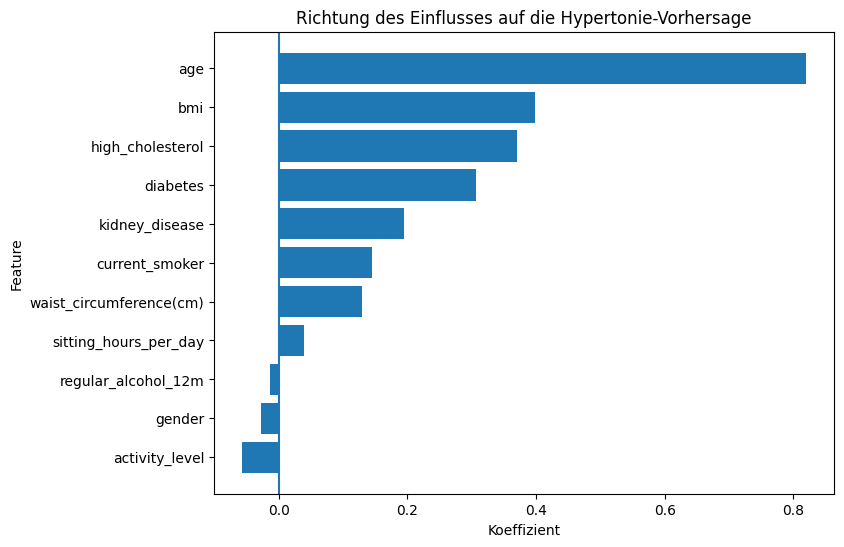

In [30]:
feature_importance_direction = feature_importance.sort_values(
    by="Coefficient", 
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    feature_importance_direction["Feature"],
    feature_importance_direction["Coefficient"]
)

plt.xlabel("Koeffizient")
plt.ylabel("Feature")
plt.title("Richtung des Einflusses auf die Hypertonie-Vorhersage")
plt.axvline(0)
plt.show()

In [35]:
df.columns

Index(['SEQN', 'hypertension', 'high_cholesterol', 'gender', 'age',
       'weight(kg)', 'height(cm)', 'bmi', 'waist_circumference(cm)',
       'diabetes', 'kidney_disease', 'current_smoker', 'regular_alcohol_12m',
       'activity_level', 'activity_level_label', 'sitting_hours_per_day',
       'bmi_category', 'age_category'],
      dtype='str')

## Fazit

Die Feature-Importance-Analyse zeigt, dass vor allem klassische demografische und klinische Risikofaktoren die Hypertonie-Vorhersage des logistischen Regressionsmodells beeinflussen. Den stärksten Einfluss hatte das Alter, gefolgt von BMI, erhöhtem Cholesterinstatus und Diabetes. Diese Ergebnisse passen zu den Beobachtungen aus der deskriptiven Analyse, in der insbesondere ältere Personen und Personen mit ungünstigeren kardiometabolischen Merkmalen häufiger Hypertonie aufwiesen.

Weitere Variablen wie chronische Nierenerkrankung, aktuelles Rauchen und Taillenumfang zeigten ebenfalls positive Koeffizienten, hatten jedoch einen geringeren Einfluss auf die Modellentscheidung. Variablen wie körperliche Aktivität, Geschlecht und Alkoholkonsum spielten im Vergleich dazu nur eine untergeordnete Rolle und sollten vorsichtig interpretiert werden.

Insgesamt unterstützt die Analyse die Auswahl der wichtigsten Eingabevariablen für die Streamlit-Anwendung. Die Ergebnisse beschreiben jedoch modellbasierte Zusammenhänge im Datensatz und dürfen nicht als kausale Ursache-Wirkungs-Beziehungen interpretiert werden.
